# Input Audio Pipeline

## 1. Import Required Libraries

In [1]:
# Import libraries for audio processing, visualization, and database operations
import matplotlib.pyplot as plt
from pathlib import Path
import time
import numpy as np

from audio_pipeline import AudioFingerprintPipeline
from audio_processing.audio import load_audio, record_audio
from audio_processing.spectrogram import spectrogram


In [2]:
# Record audio from the microphone
for i in range(3, 0, -1):
    print(f"\r--- Recording starts in {i} seconds ---")
    time.sleep(0.5)
print("Recording now...")
y_mic, sr_mic = record_audio(duration=7)
print("Recording done.")
print(f"Shape of input: {y_mic.shape}")

print(f"Audio min: {y_mic.min():.6f}, max: {y_mic.max():.6f}")
print(f"Audio mean: {y_mic.mean():.6f}, std: {y_mic.std():.6f}")


--- Recording starts in 3 seconds ---
--- Recording starts in 2 seconds ---
--- Recording starts in 1 seconds ---
Recording now...
Recording done.
Shape of input: (154350,)
Audio min: -0.008962, max: 0.009082
Audio mean: -0.000001, std: 0.003038


In [3]:
# Load original clean 0022 audio for comparison
original_file = Path("data", "assets", "clean_wavs", "music-hd-0022.wav")
y_orig, sr_orig = load_audio(original_file.as_posix())
print(f"Loaded clean audio - shape: {y_orig.shape}, sr: {sr_orig}, length in seconds: {len(y_orig) / sr_orig:.2f}")

Loaded clean audio - shape: (3670273,), sr: 22050, length in seconds: 166.45


Raw audio shape: (154350,), sample rate: 22050, duration: 7.00 seconds


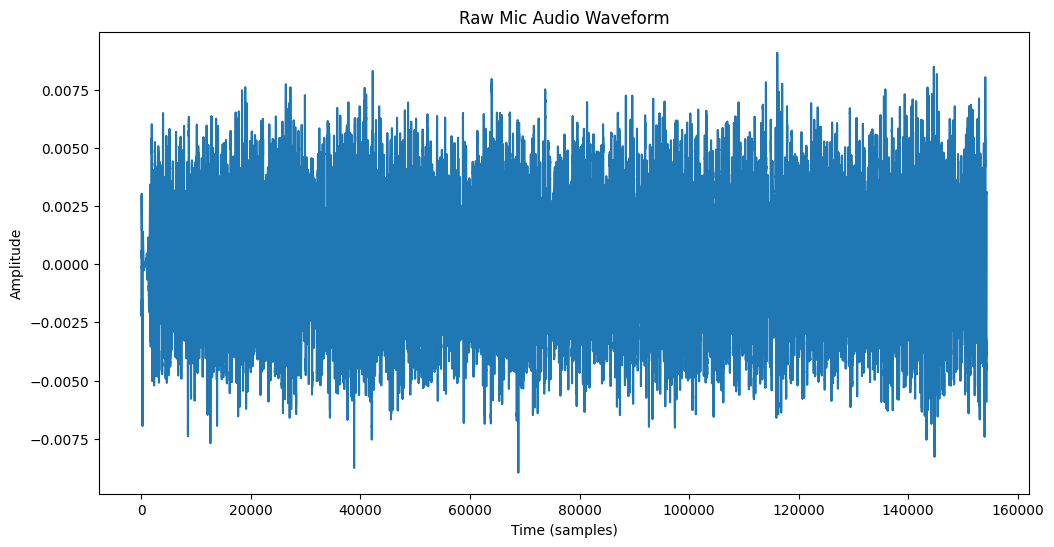

In [5]:
# Display Waveform
audio_pipeline = AudioFingerprintPipeline()
results = audio_pipeline.run(y_mic, save_checkpoints=True)

# Render raw waveform
waveform = results["raw"]
print(f"Raw audio shape: {waveform.shape}, sample rate: {sr_mic}, duration: {len(waveform) / sr_mic:.2f} seconds")
plt.figure(figsize=(12, 6))
plt.plot(waveform)
plt.title("Raw Mic Audio Waveform")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

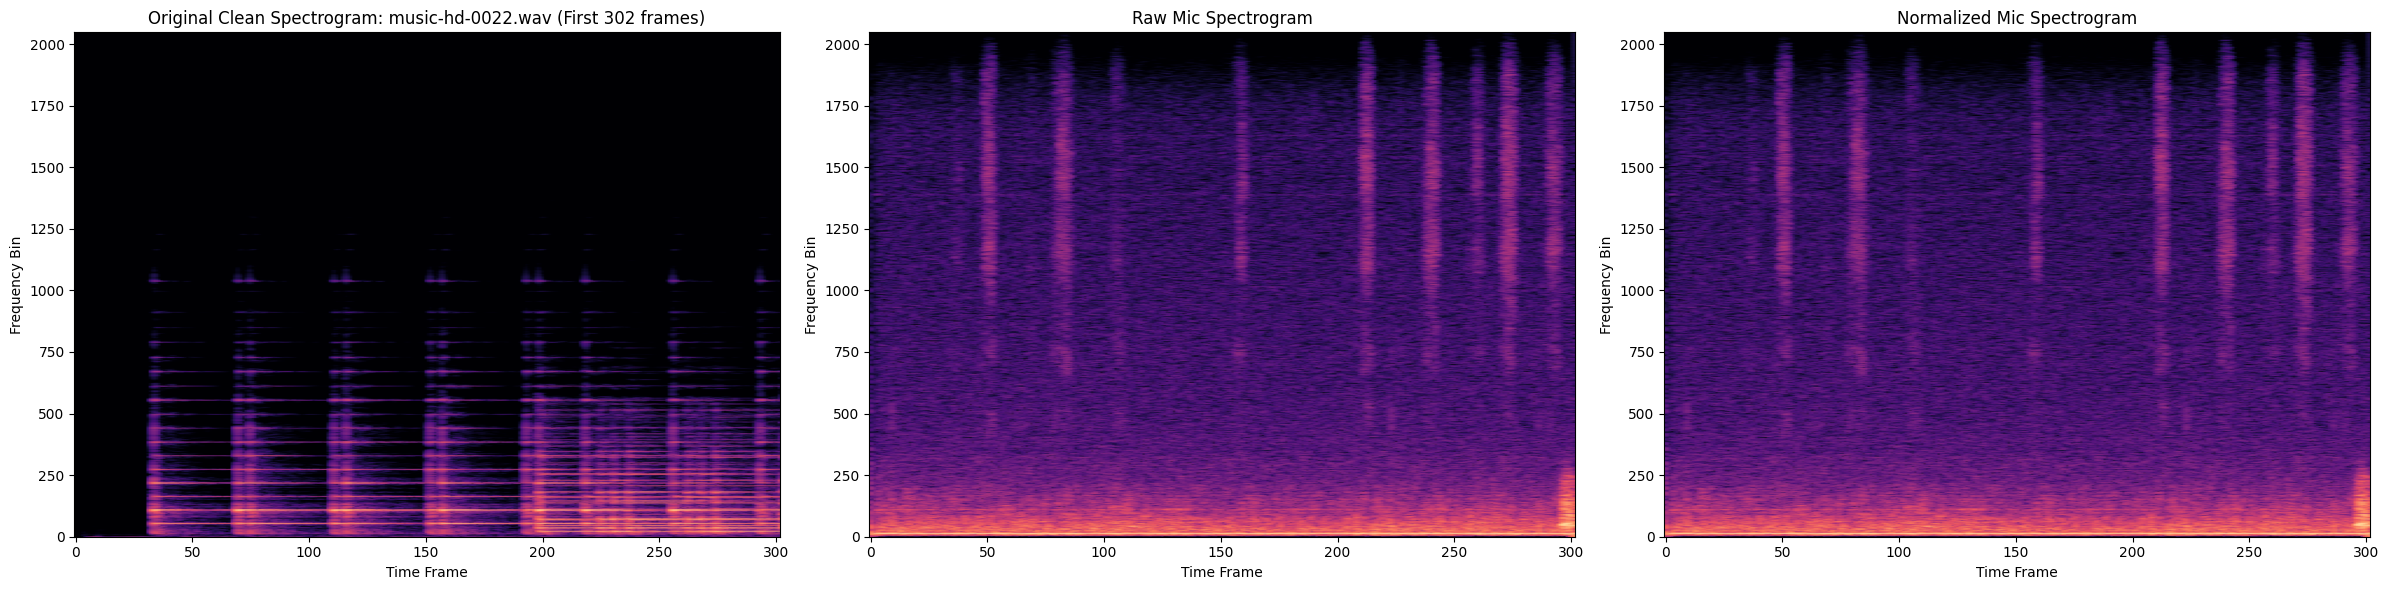

In [ ]:
S_db_mic_normalized = spectrogram(results["normalized"])

S_db_orig = spectrogram(y_orig)
S_db_raw_mic = spectrogram(y_mic)

# Slice original to match mic length
mic_time_frames = S_db_raw_mic.shape[1]
S_db_original_slice = S_db_orig[:, :mic_time_frames]

# Show side-by-side spectrograms
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

axes[0].imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Original Clean Spectrogram: {original_file.name} (First {mic_time_frames} frames)")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

axes[1].imshow(S_db_raw_mic, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Raw Mic Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

axes[2].imshow(S_db_mic_normalized, aspect="auto", origin="lower", cmap="magma")
axes[2].set_title("Normalized Mic Spectrogram")
axes[2].set_xlabel("Time Frame")
axes[2].set_ylabel("Frequency Bin")

plt.tight_layout()
plt.show()

# Define other variables
sr_mic = DEFAULT_SR
amp_min = -60
noise_length = int(0.5 * sr_mic)
if len(y_mic) > noise_length:
    noise_clip = y_mic[:noise_length]
else:
    noise_clip = y_mic

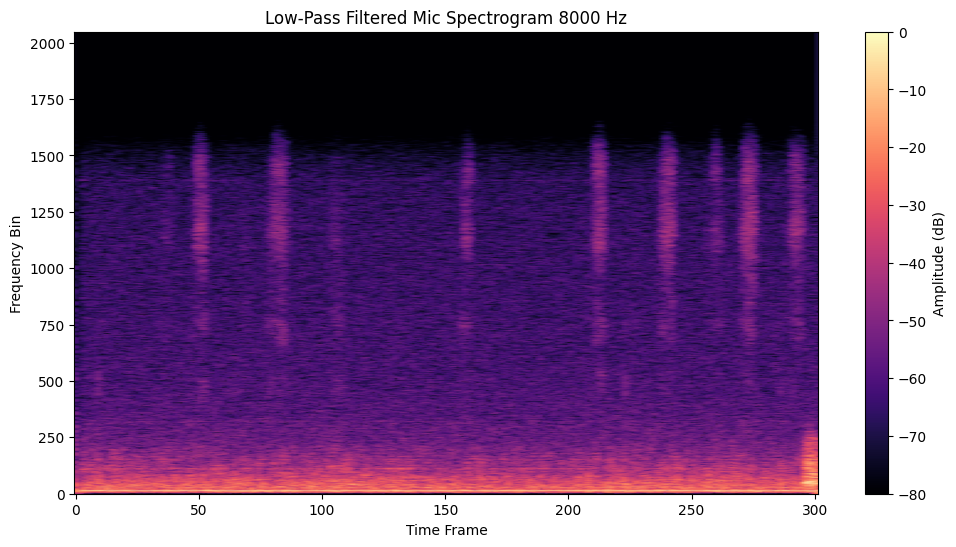

In [ ]:
# 2. Low-Pass Filtered (removes high frequencies)
S_db_mic_lowpass = spectrogram(results["lowpass"])

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_lowpass, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Low-Pass Filtered Mic Spectrogram 8000 Hz")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()


dict_keys(['normalized', 'lowpass', 'spectrogram', 'enhanced', 'peaks', 'fingerprints'])
Max db is 0.00 dB, min db is -75.00 dB


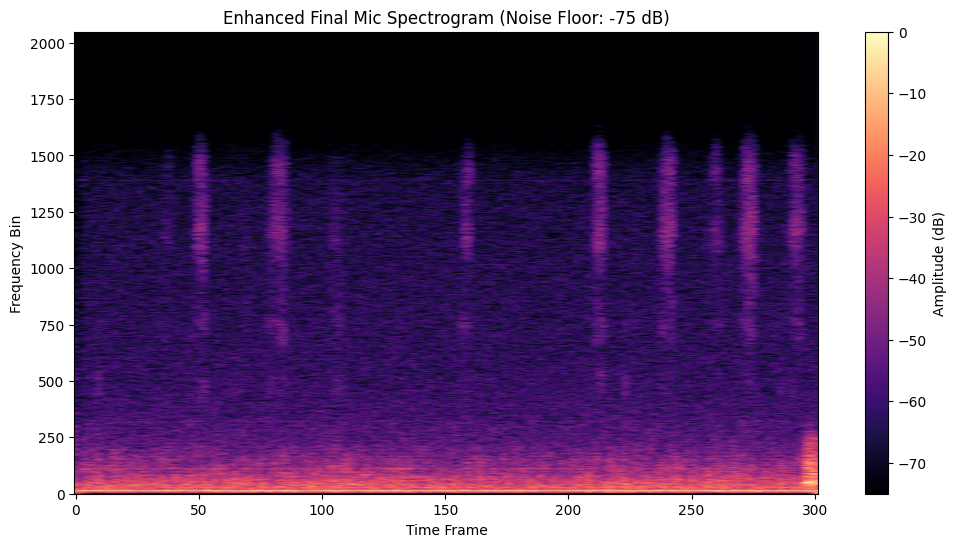

In [ ]:
# Enhance Peaks: Apply a noise floor to make peaks more evident by reducing background noise
print(results.keys())
S_db_enhanced = results["enhanced"]
print(f"Max db is {S_db_enhanced.max():.2f} dB, min db is {S_db_enhanced.min():.2f} dB")
plt.figure(figsize=(12, 6))
plt.imshow(S_db_enhanced, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Enhanced Final Mic Spectrogram (Noise Floor: -75 dB)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()



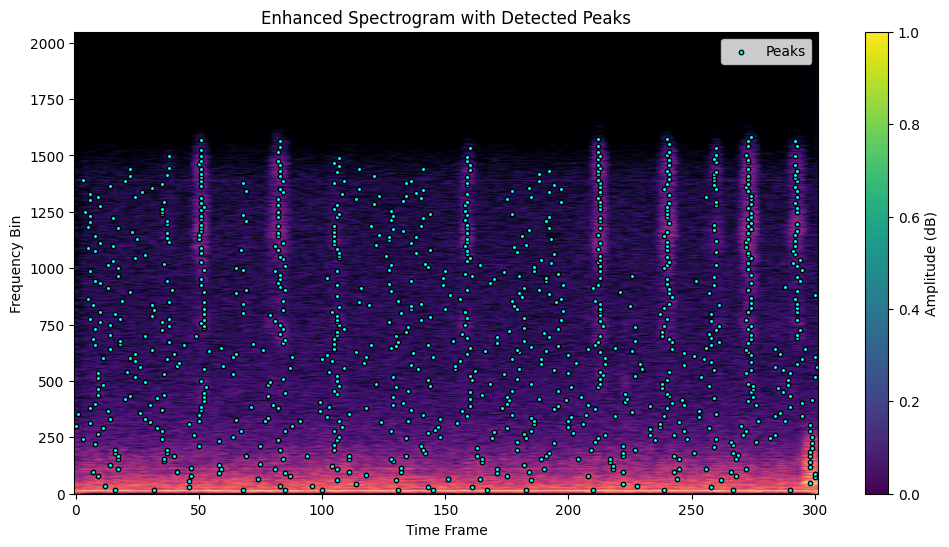

In [ ]:
peaks = np.array(results["peaks"])

plt.figure(figsize=(12, 6))
plt.imshow(S_db_enhanced, aspect="auto", origin="lower", cmap="magma")
plt.scatter(peaks[:, 0], peaks[:, 1], color="cyan", label="Peaks", s=10, edgecolors="black")
plt.colorbar(label="Amplitude (dB)")
plt.title("Enhanced Spectrogram with Detected Peaks")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.legend()
plt.show()